# Milestone 4, step 1 — photo check of the 40 biggest ring losses

The list is fixed by `m4_ring_gate.ipynb`: the 40 OSM lakes of 1 ha or more whose clean ring (the
10-30 m bands of the 30 m buffer) lost the most normalised greenness from 2019 to 2026, readable or
not. `render_ring_losses.py` wrote the evidence (`results/m4_ring_evidence.csv`) and the frames
(`results/m4_ring_photos/`). Every lake on the list is looked at before any of it is quoted.

1. **Water in the ring**: the share of the clean ring's pixels that read as open water (MNDWI above
   zero, counted per pixel on the pinned grid), per dry season. Water rising into the ring turns
   grass into water and reads as loss — M2's top four losses were exactly that.
2. **The photos**: Sentinel-2 true colour for the eight dry seasons, lake in yellow, outer edge of
   the 30 m ring in cyan. The verdicts also used the Esri high-resolution photo of each lake, which
   `render_ring_losses.py` saves locally; it is not embedded here because its licence is for viewing,
   not redistribution.
3. **A verdict for every one of the 40**, stored in `results/m4_ring_verdicts.csv`, against the
   readability flag and against a 2020 start year.

Sections 1 and 3 run without Earth Engine; section 2 reads the frames from disk.

In [1]:
import io
import os
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image as Show, display
from PIL import Image, ImageDraw

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(REPO)
sys.path.insert(0, str(REPO))
from render_ring_losses import HEX_TABLE, PHOTOS, TABLE, TOP, YEARS, clean_series

HEADLINE = ("real loss",)
FRAME_PX = 200

evidence = pd.read_csv("results/m4_ring_evidence.csv")
verdicts = pd.read_csv("results/m4_ring_verdicts.csv")
assert list(verdicts.osm) == list(evidence.osm)
year_mean = pd.read_csv(HEX_TABLE).pivot(index="h3", columns="year", values="green").mean(axis=0)
norm = clean_series(pd.read_csv(TABLE), year_mean)
print(f"{len(evidence)} lakes, ranks 1-{TOP}; {evidence.readable.sum()} of them readable")

40 lakes, ranks 1-40; 4 of them readable


---
## 1 — Water in the ring

In [2]:
water = evidence.set_index("rank")[[f"ring_water_{y}" for y in YEARS]]
water.columns = YEARS
wet = water[(water > 0.05).any(axis=1)]
print(f"lakes with more than 5% open water in the clean ring in any year: {len(wet)} of {TOP}")
print(wet.map(lambda v: f"{v:.0%}").assign(name=evidence.set_index("rank").name).to_string())
print(f"\nlargest share on the whole list in 2019: {water[2019].max():.0%}, in 2026: {water[2026].max():.0%}")

lakes with more than 5% open water in the clean ring in any year: 4 of 40
     2019 2020 2021 2022 2023 2024 2025 2026                name
rank                                                            
3      2%   5%   2%   8%   5%   0%   0%   0%      Heelalige Lake
5      6%   6%   0%   0%   0%   0%   0%   0%          Hoodi Lake
6      7%   3%   0%   0%   0%   0%   0%   0%  Mallathahalli Lake
14     1%   6%  14%  24%  38%  25%  31%  40%                 NaN

largest share on the whole list in 2019: 7%, in 2026: 40%


---
## 2 — The photos

One row per lake, 2019 top left to 2026 bottom right. The number under each year is the normalised
greenness of the clean ring; the change is the last minus the first.

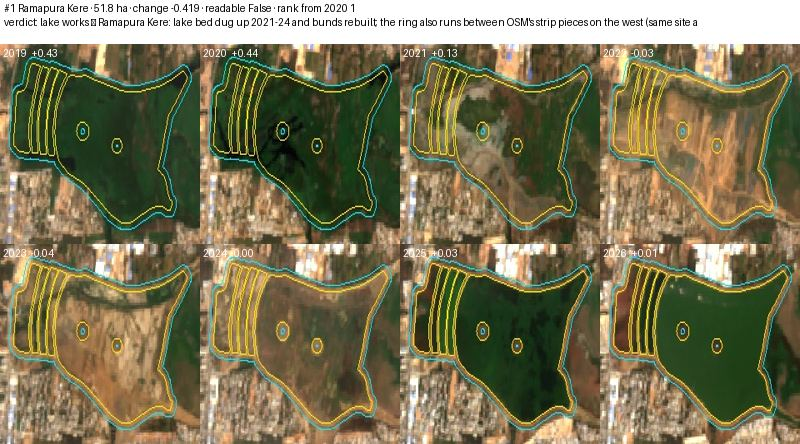

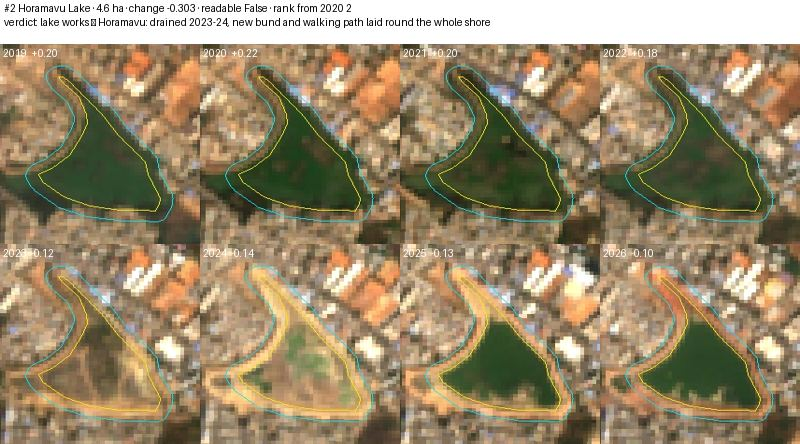

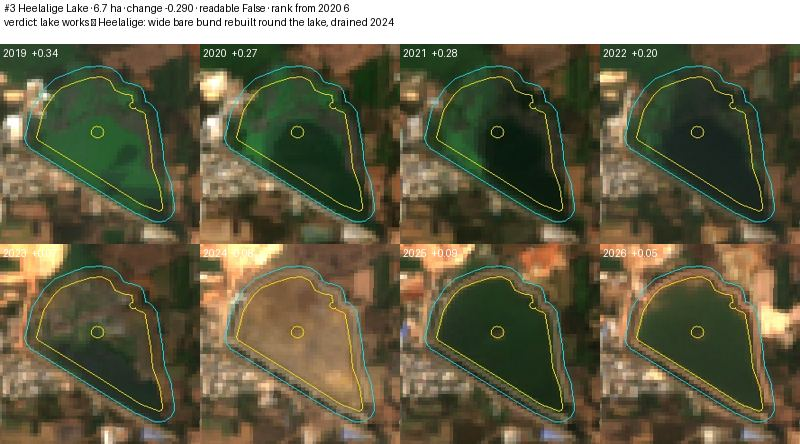

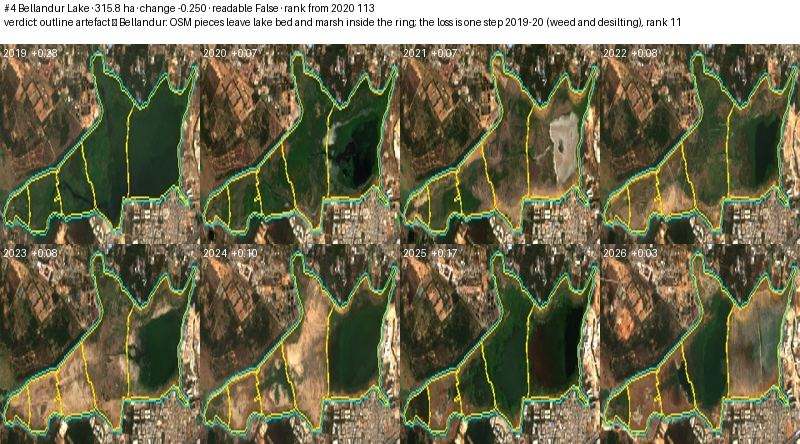

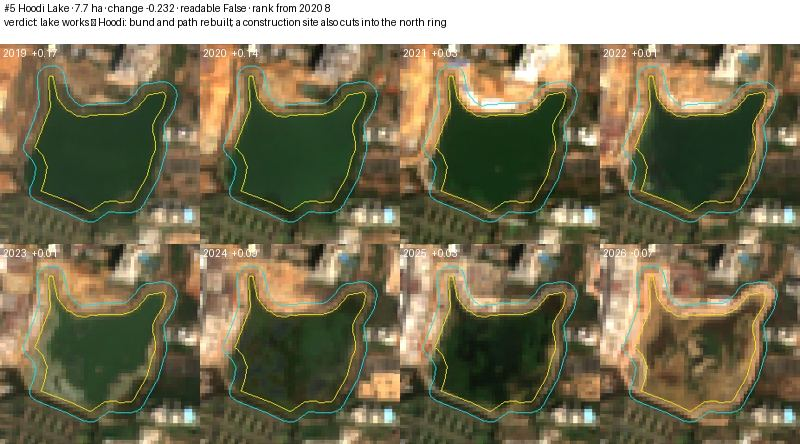

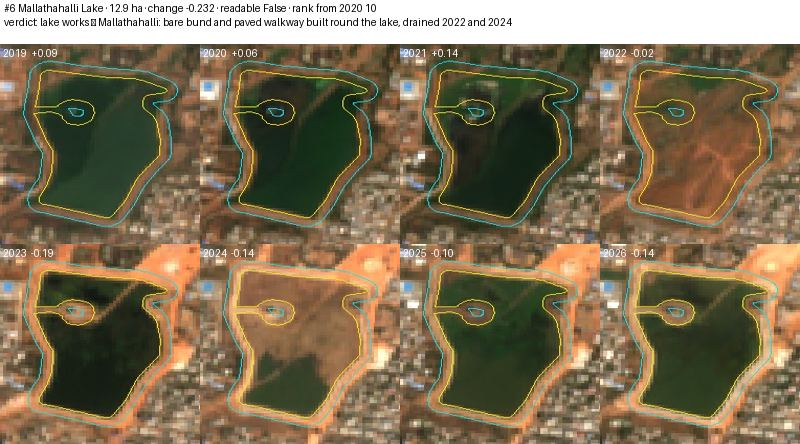

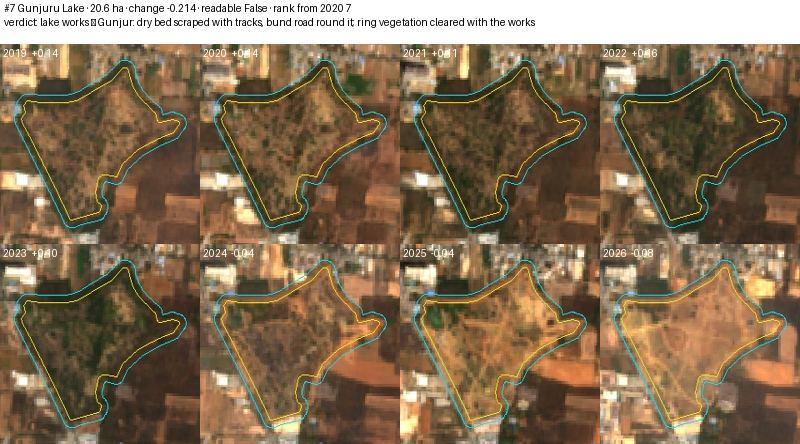

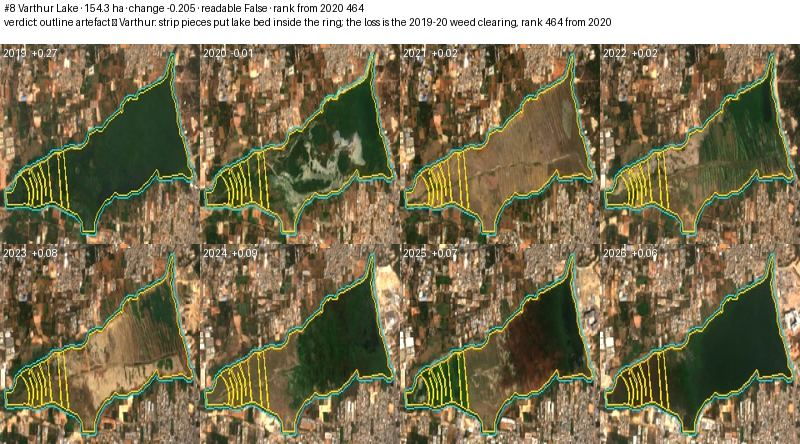

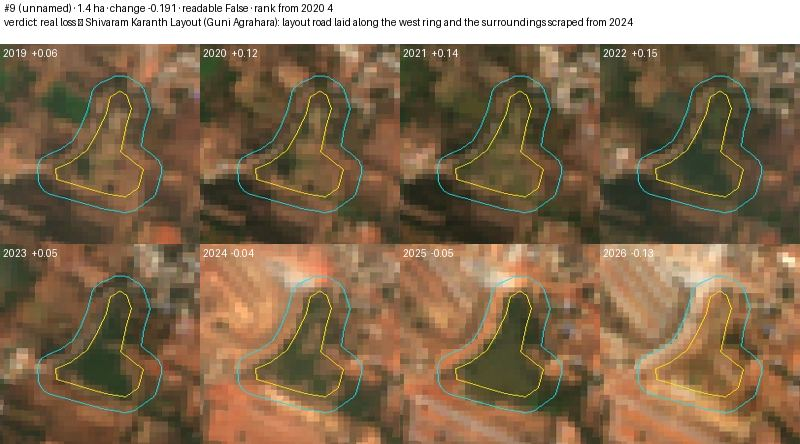

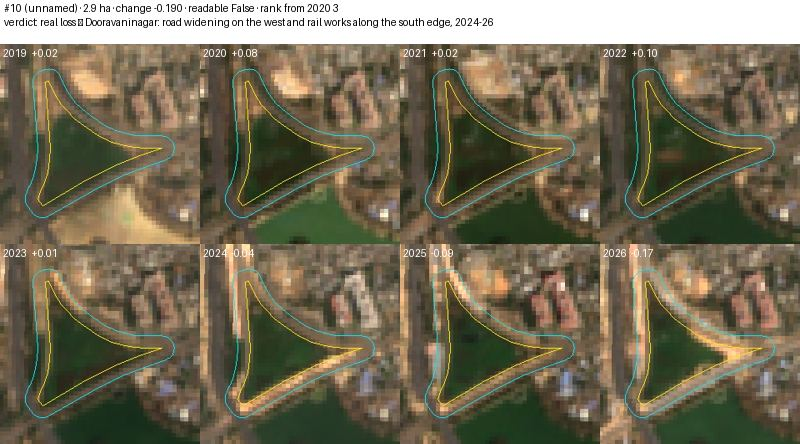

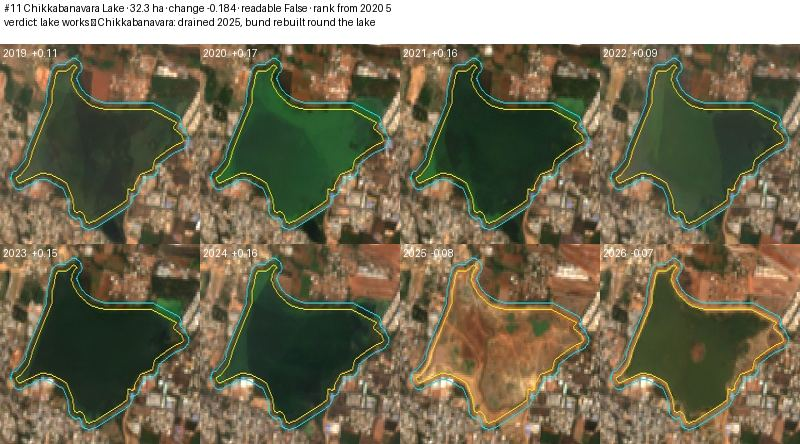

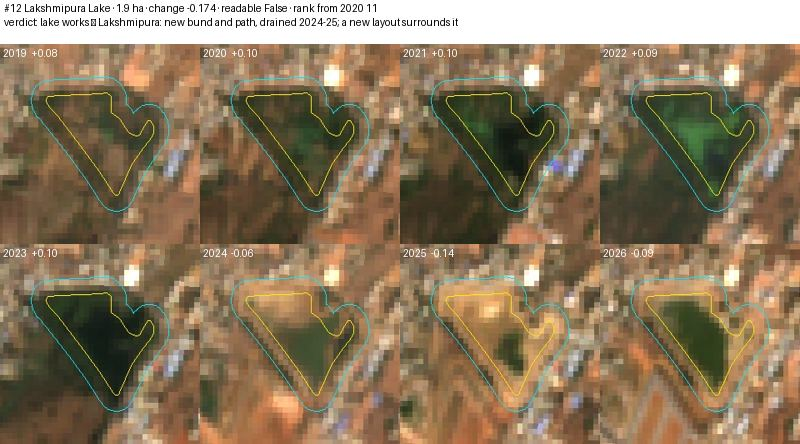

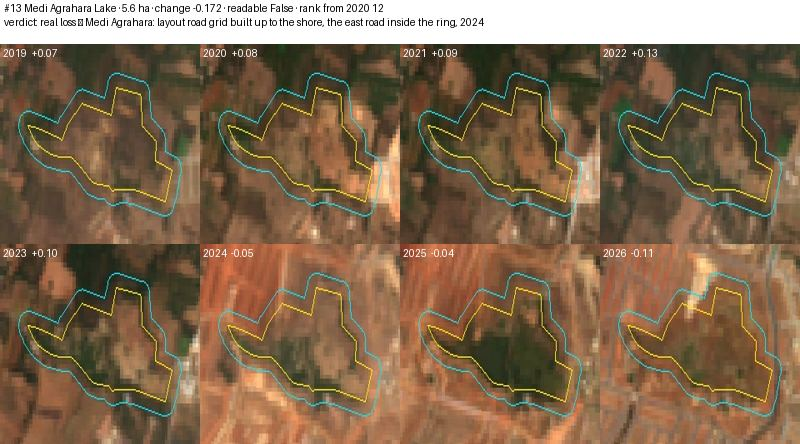

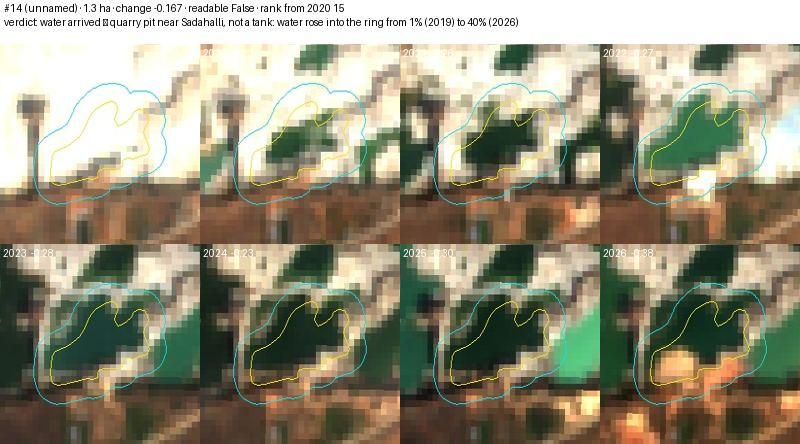

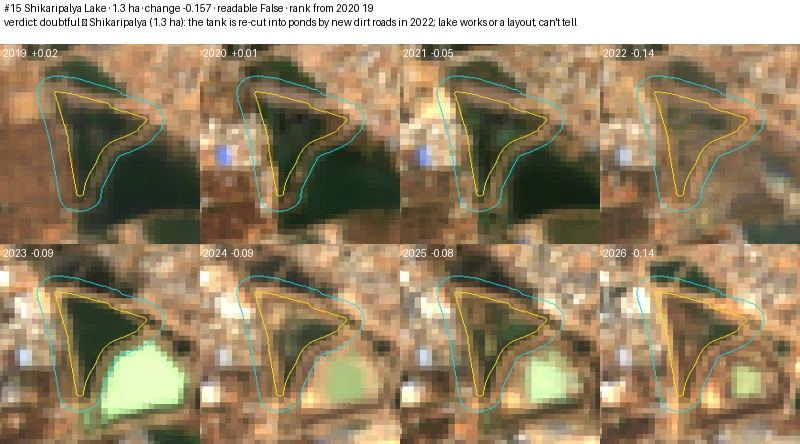

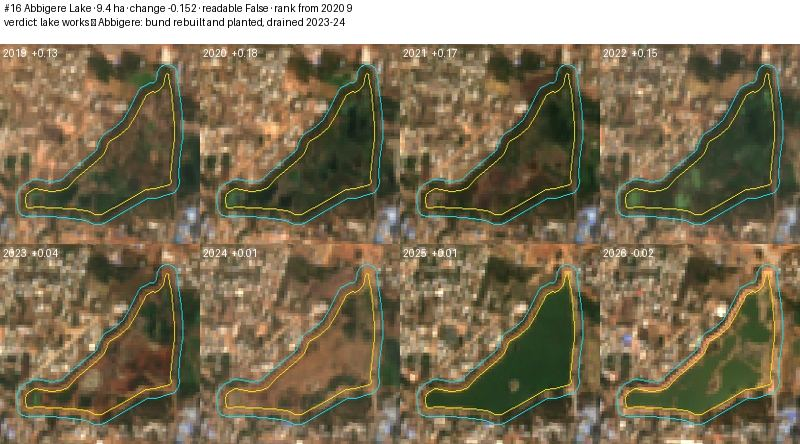

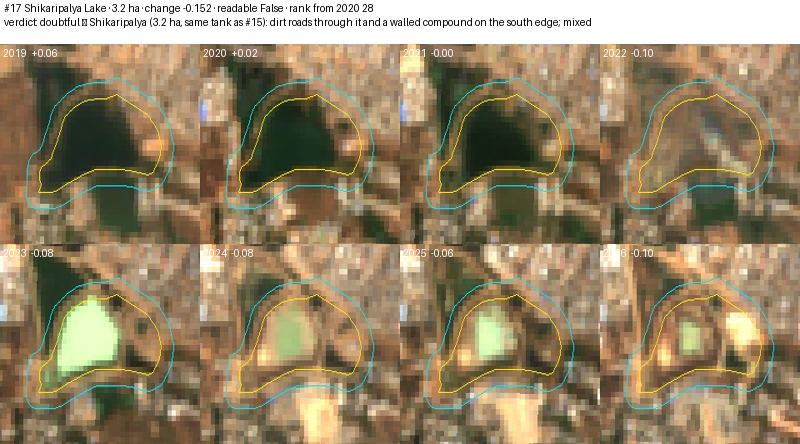

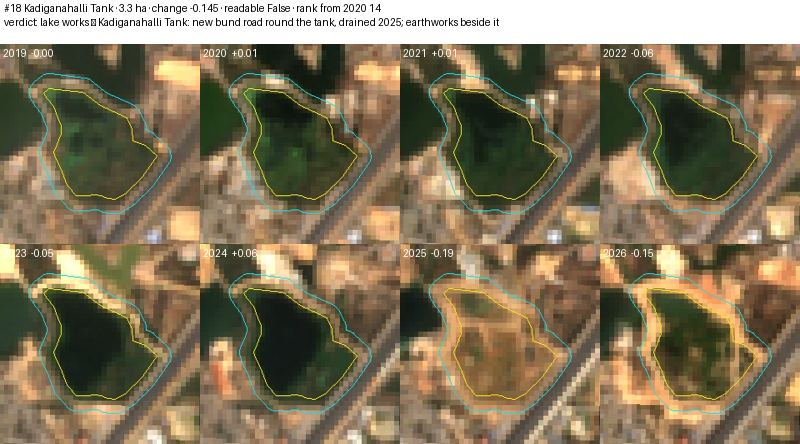

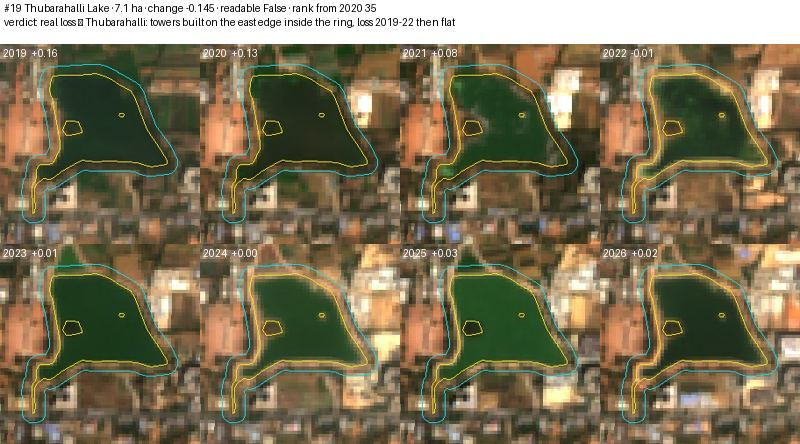

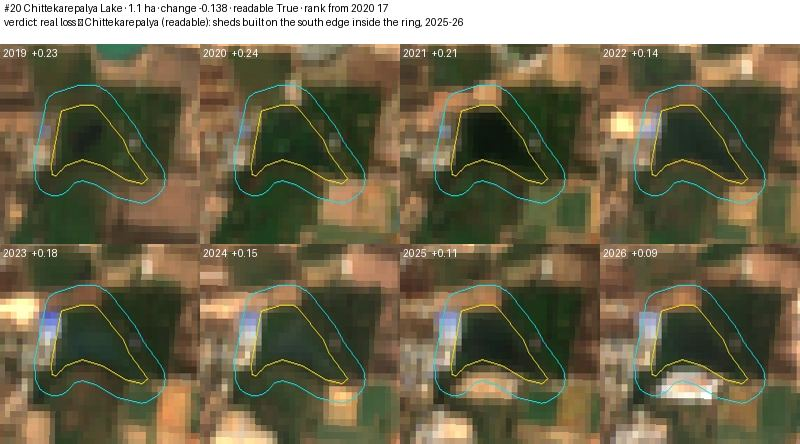

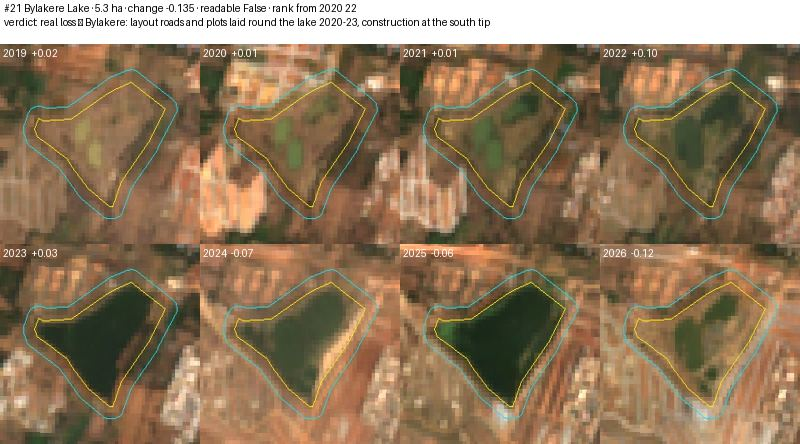

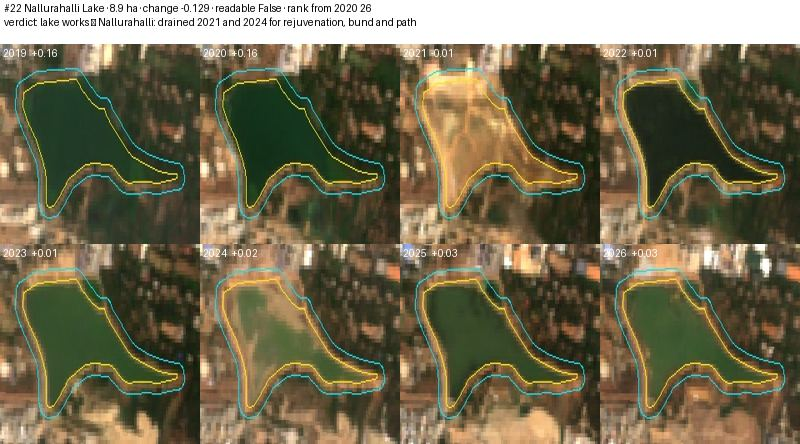

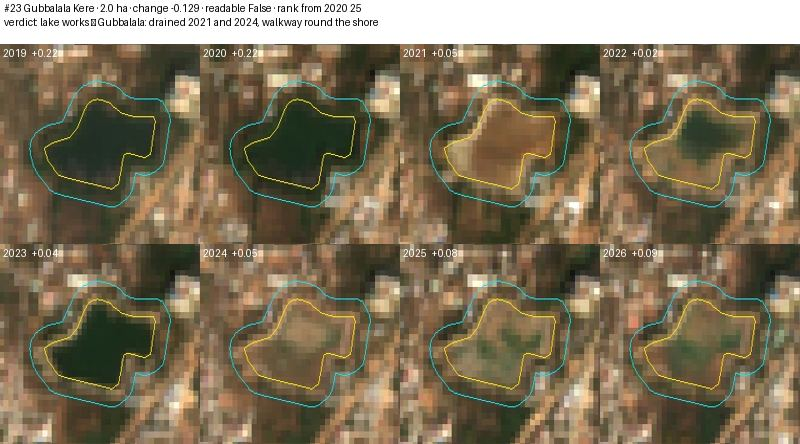

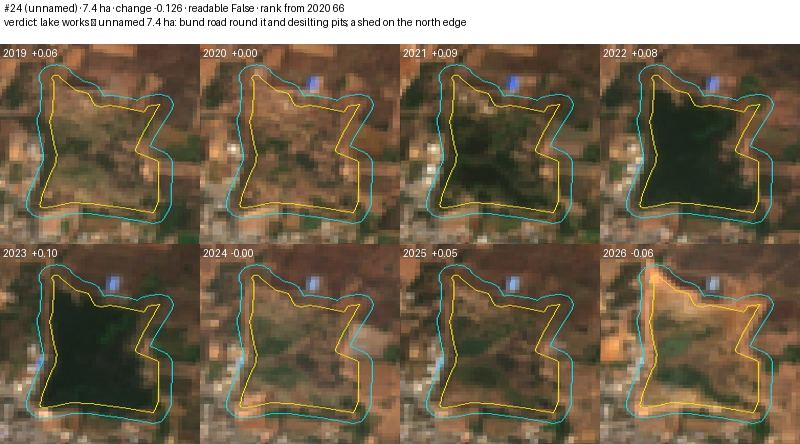

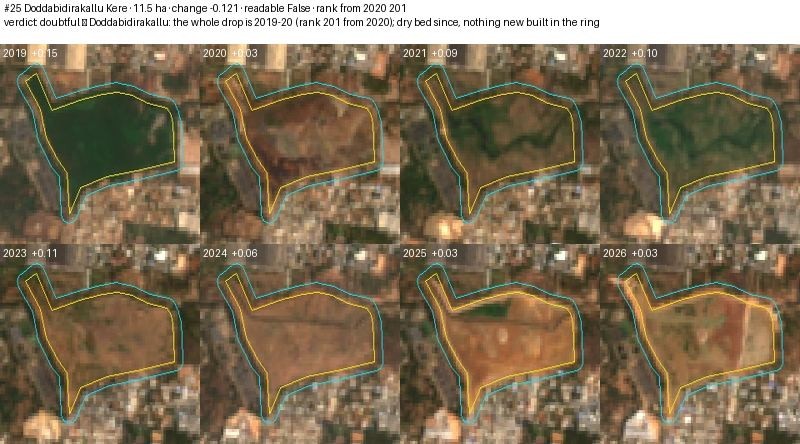

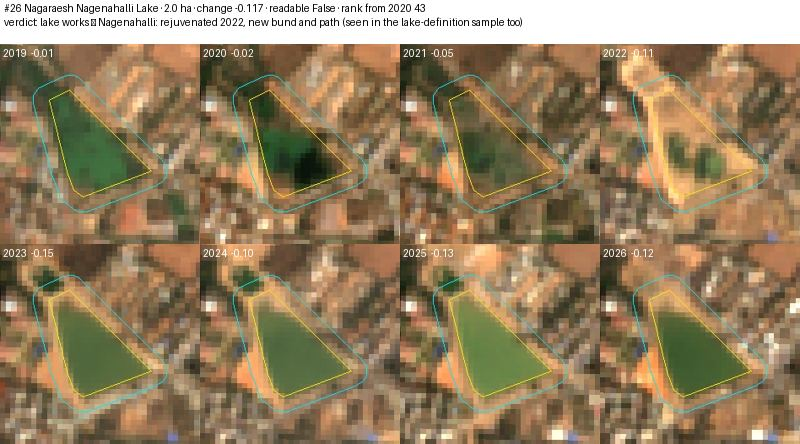

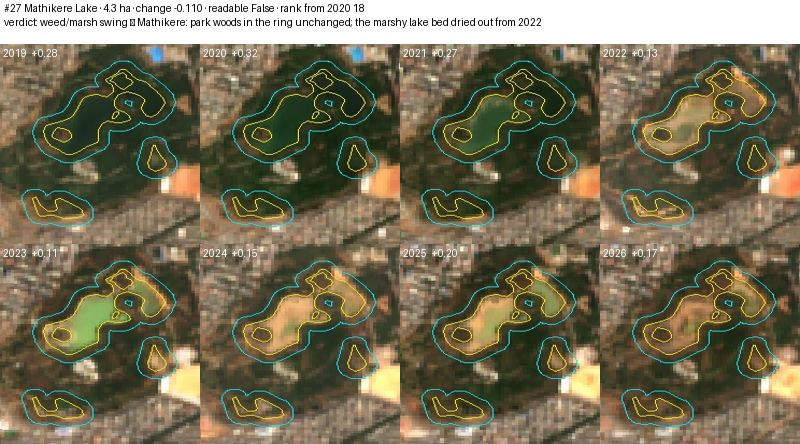

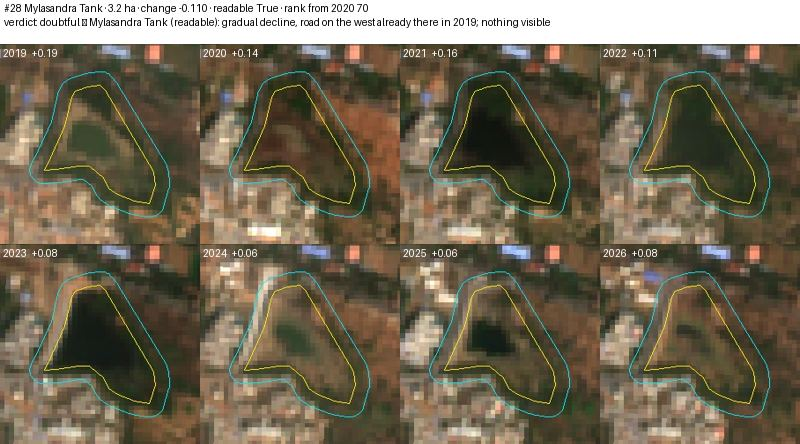

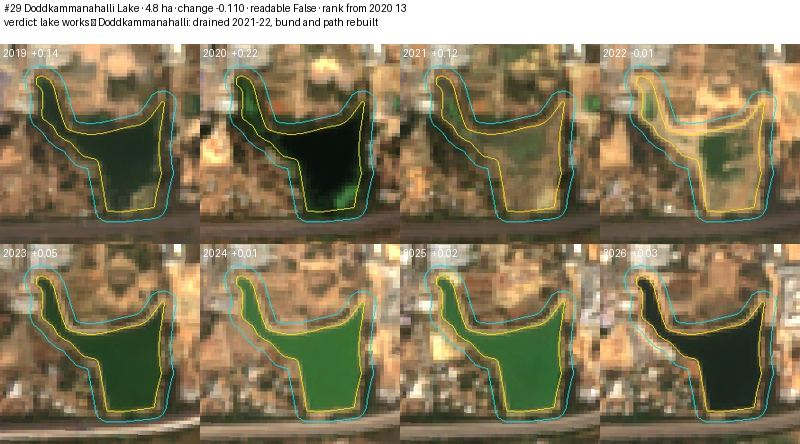

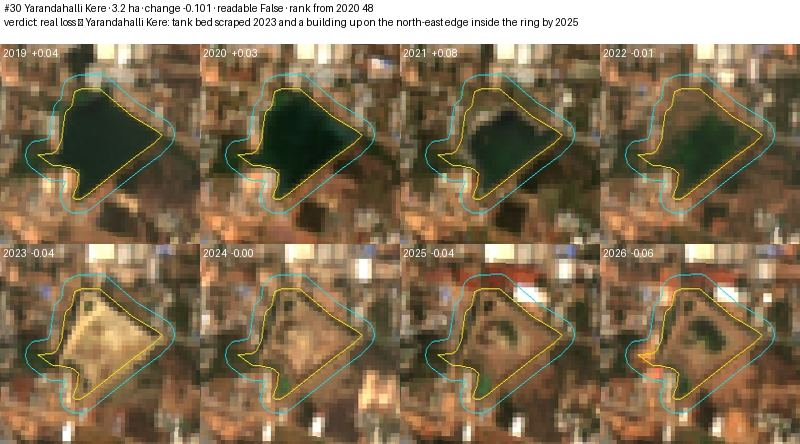

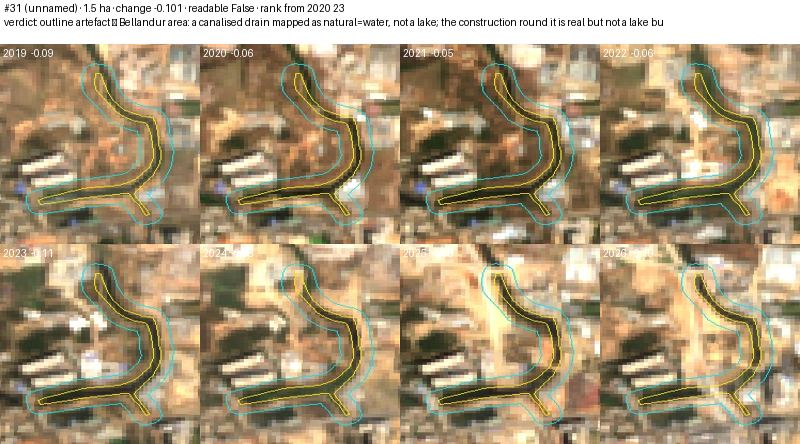

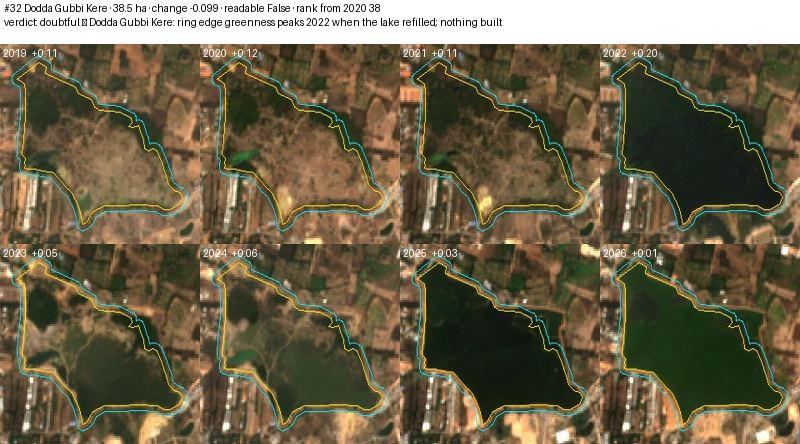

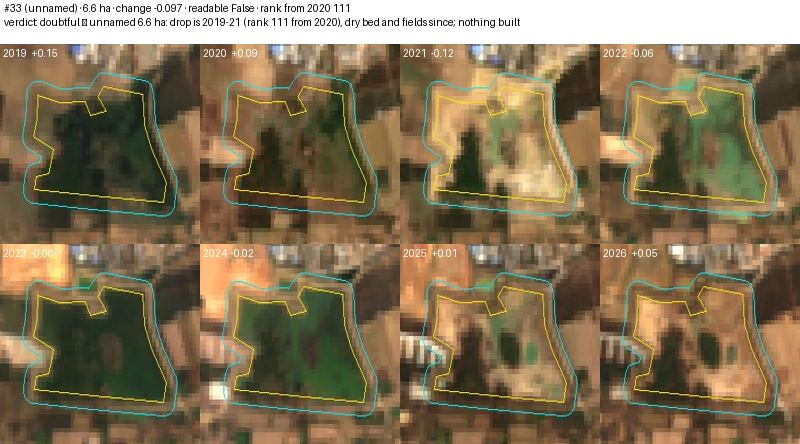

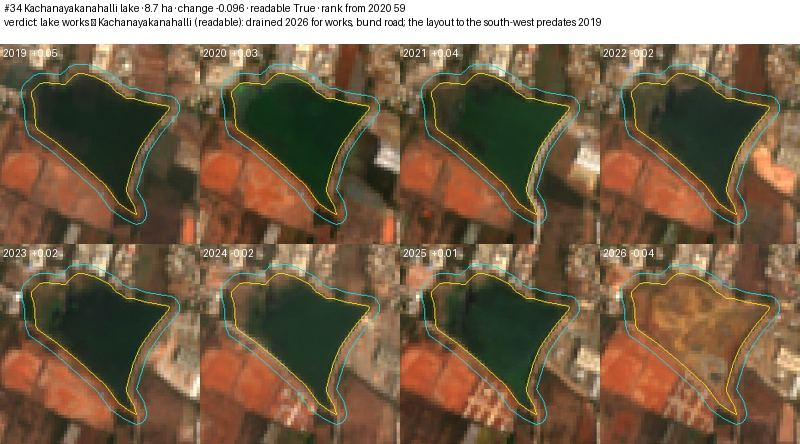

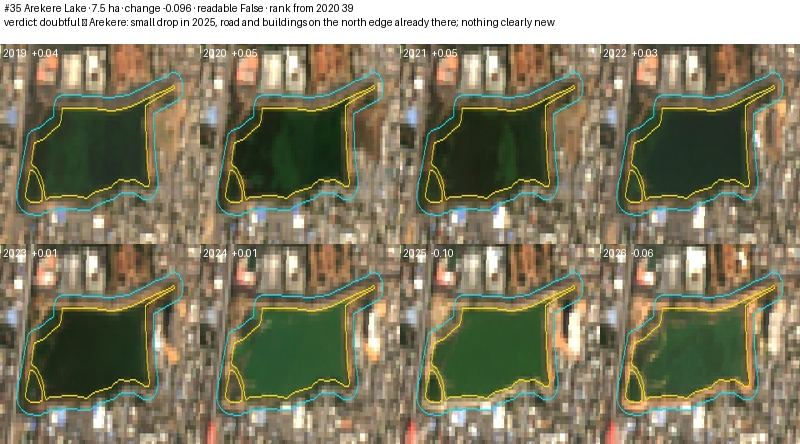

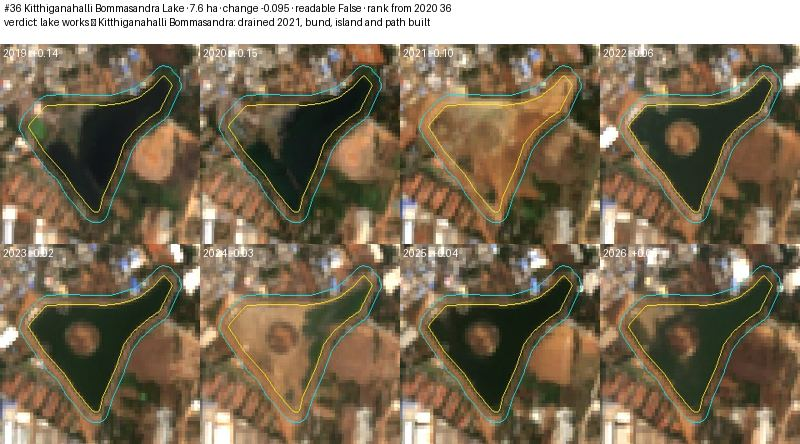

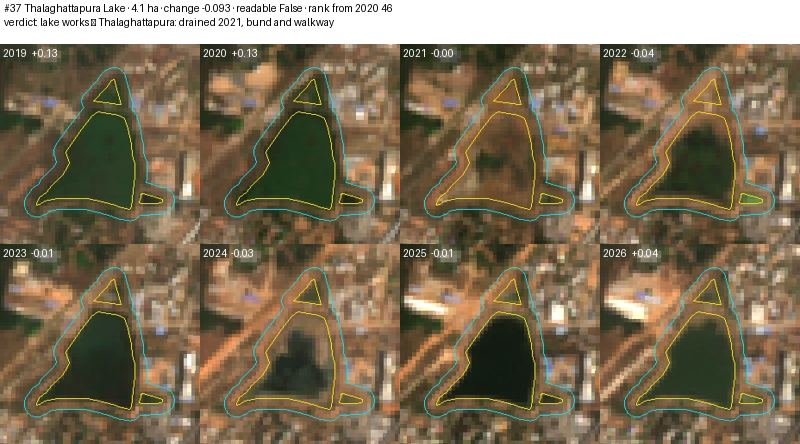

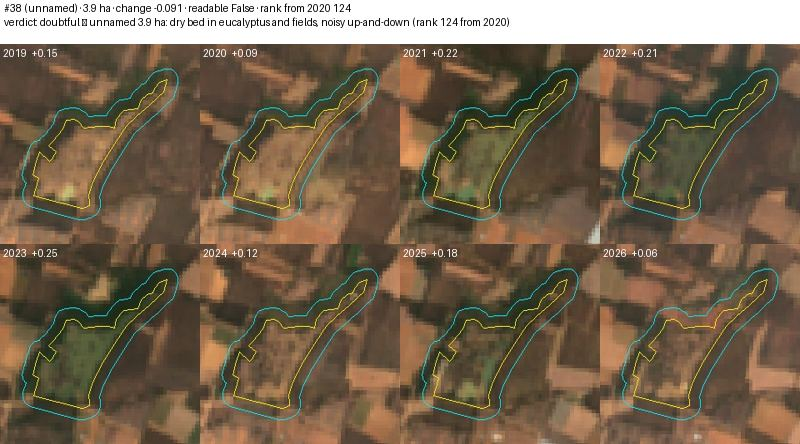

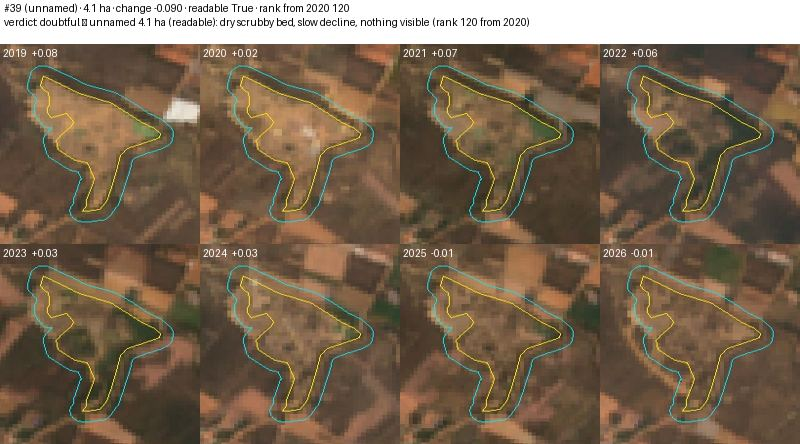

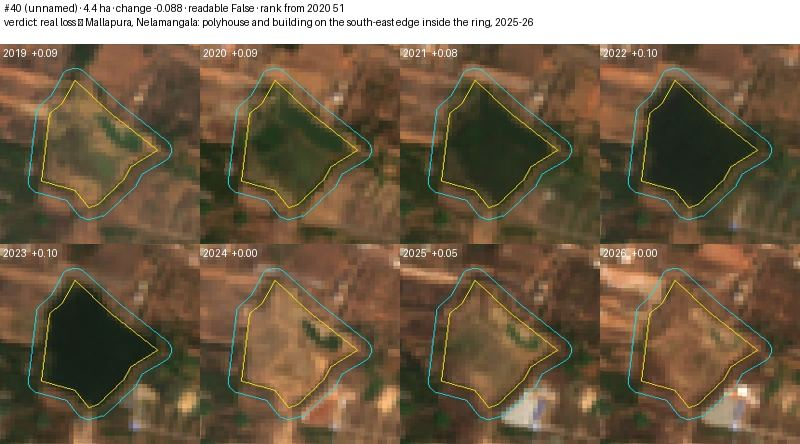

In [3]:
def row(r) -> bytes:
    sheet = Image.new("RGB", (4 * FRAME_PX, 2 * FRAME_PX + 44), "white")
    draw = ImageDraw.Draw(sheet)
    draw.text((4, 2), f"#{r.rank} {r.name if isinstance(r.name, str) else '(unnamed)'} · {r.ha:.1f} ha · "
              f"change {r.change:+.3f} · readable {r.readable} · rank from 2020 {r.rank_from_2020}", fill="black")
    draw.text((4, 16), f"verdict: {r.verdict} — {r.note}"[:150], fill="black")
    for k, y in enumerate(YEARS):
        frame = Image.open(PHOTOS / f"{r.osm.replace(';', '_')}_{y}.jpg").resize((FRAME_PX, FRAME_PX))
        x, top = (k % 4) * FRAME_PX, 44 + (k // 4) * FRAME_PX
        sheet.paste(frame, (x, top))
        draw.text((x + 3, top + 3), f"{y}  {norm.loc[r.osm, y]:+.2f}", fill="white")
    out = io.BytesIO()
    sheet.save(out, "JPEG", quality=78)
    return out.getvalue()


for r in evidence.merge(verdicts[["osm", "verdict", "note"]], on="osm").itertuples():
    display(Show(row(r)))

---
## 3 — A verdict for every one of the 40

Written by eye from the frames above and the Esri photos. Below: the counts, the verdicts against
the readability flag, and which lakes leave the top 40 if the start year is 2020.

In [4]:
print(verdicts.verdict.value_counts().to_string())
print(f"\nheadline list (real loss): {verdicts.verdict.isin(HEADLINE).sum()} of {TOP}\n")
print(pd.crosstab(verdicts.verdict, verdicts.readable.map({True: "readable", False: "unreadable"}),
                  margins=True).to_string())
moved = verdicts[verdicts.rank_from_2020 > TOP]
print(f"\nleave the top {TOP} with a 2020 start: {len(moved)}")
print(moved[["rank", "rank_from_2020", "name", "verdict"]].to_string(index=False))
print("\nthe real losses:")
print(verdicts[verdicts.verdict.isin(HEADLINE)][["rank", "rank_from_2020", "name", "ha", "change", "readable", "note"]]
      .to_string(index=False))

verdict
lake works          18
doubtful             9
real loss            8
outline artefact     3
water arrived        1
weed/marsh swing     1

headline list (real loss): 8 of 40

readable          readable  unreadable  All
verdict                                    
doubtful                 2           7    9
lake works               1          17   18
outline artefact         0           3    3
real loss                1           7    8
water arrived            0           1    1
weed/marsh swing         0           1    1
All                      4          36   40

leave the top 40 with a 2020 start: 13
 rank  rank_from_2020                       name          verdict
    4             113             Bellandur Lake outline artefact
    8             464               Varthur Lake outline artefact
   24              66                        NaN       lake works
   25             201      Doddabidirakallu Kere         doubtful
   26              43 Nagaraesh Nagenahalli Lake   

---
## What this shows

**Lake works, not encroachment, dominate the top of the ring ranking.** 18 of the 40 are
rejuvenation: a lake drained, its bund rebuilt as a bare or paved walkway, its bed desilted. The
ring is exactly where a bund and a walking path go, so a rejuvenated lake reads as vegetation lost
in its own buffer. All of the top eight are lake works (six) or outline artefacts (Bellandur, Varthur).

| verdict | count | what they are |
|---|---|---|
| lake works | 18 | Ramapura, Horamavu, Heelalige, Hoodi, Mallathahalli, Gunjur, Chikkabanavara, Lakshmipura, Abbigere, Kadiganahalli, Nallurahalli, Gubbalala, Nagenahalli, Doddkammanahalli, Kachanayakanahalli, Kitthiganahalli Bommasandra, Thalaghattapura, one unnamed |
| real loss | 8 | roads, layouts, towers, sheds and a polyhouse built inside the ring: Shivaram Karanth Layout (Guni Agrahara), Dooravaninagar, Medi Agrahara, Thubarahalli, Chittekarepalya, Bylakere, Yarandahalli, Mallapura |
| doubtful | 9 | nothing visible built, or a drop that is all 2019-20 |
| outline artefact | 3 | Bellandur and Varthur (lake bed between OSM's pieces sits in the ring), and a canalised drain mapped as a lake |
| water arrived | 1 | a flooding quarry pit, not a tank |
| weed/marsh swing | 1 | Mathikere, the lake bed drying |

**Water is not the explanation this time.** Only one of the 40 has more than 10% open water in its
clean ring in any year, a quarry pit; the shoreline band that would carry it was dropped at step 0.
The failure that dominated M2's top losses does not carry over; lake works replace it.

**Readability does not pick the real losses.** Only 4 of the 40 are readable: one real loss
(Chittekarepalya), one lake works (Kachanayakanahalli) and two doubtful. The sudden changes that
make a story are exactly what makes a ring's scatter too high, as the gate expected, so the photo
check, not the flag, is what decides.

**The 2019 start year matters most for the doubtful and the artefacts.** 13 of the 40 leave the top
40 with a 2020 start: both artefacts (Bellandur to 113, Varthur to 464), 5 of the 9 doubtful
(Doddabidirakallu to 201), 4 lake works and 2 real losses (Yarandahalli to 48, Mallapura to 51).
6 of the 8 real losses stay in the top 40 either way.

**For the published story:** eight quotable cases of building inside a lake's 30 m ring, several
of them in new layouts (Shivaram Karanth, Medi Agrahara, Bylakere) the M2 hex losses already point
at. Lake works are real vegetation removal inside the buffer but carried out by the lake's own
custodians; whether they go in the story is the same editorial call as M2's provisional lake-works
decision.